# Quickstart

This notebook fits scIToFlow end to end in a few minutes, on CPU, using the built-in
{func}`scitoflow.simulate_dataset`. You will:

1. simulate a small spatial multi-omic dataset,
2. build and train the `full` model, and
3. read out the inferred **spatial latent time** and compare it to the ground truth.

```{note}
The model runs in double precision, so we set the default dtype to `float64` once at the
top. Every input tensor you pass to the model should be `float64` as well.
```

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)
np.random.seed(0)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": False})
NICHE_COLORS = ["#E69F00", "#56B4E9", "#009E73"]  # Okabe-Ito, colorblind-safe

## 1. Simulate a dataset

`simulate_dataset` returns an `AnnData` with the moment-smoothed layers the model
consumes (`M_c` chromatin, `M_u` unspliced, `M_s` spliced), spatial coordinates, and a
ground-truth `latent_time` and `niche` label we can validate against.

In [2]:
from scitoflow import simulate_dataset

adata = simulate_dataset(n_genes=50, grid=20, n_niches=3, seed=0)
adata

/home/bernaljp/micromamba/envs/scitoflow/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 400 × 50
    obs: 'x_position', 'y_position', 'latent_time', 'stage', 'niche'
    layers: 'M_c', 'M_u', 'M_s', 'M_n', 'M_t'

The spots lie on a 20x20 grid. Latent time increases along the diagonal, and three spatial
niches band the tissue. Here is the ground truth we will try to recover, plus one gene's
spliced signal.

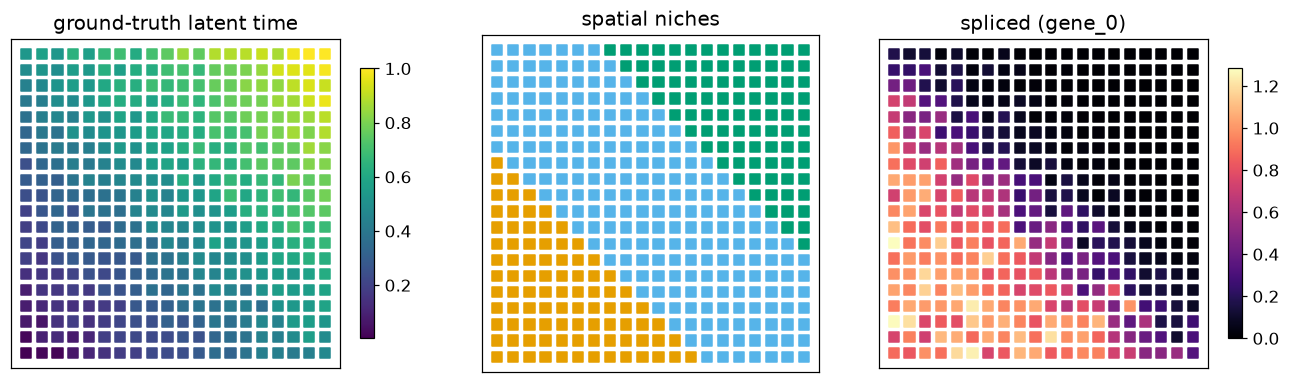

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
x, y = adata.obs["x_position"], adata.obs["y_position"]

sc0 = axes[0].scatter(x, y, c=adata.obs["latent_time"], cmap="viridis", s=45, marker="s")
axes[0].set_title("ground-truth latent time")
plt.colorbar(sc0, ax=axes[0], shrink=0.8)

niche = adata.obs["niche"].astype(int).values
axes[1].scatter(x, y, c=[NICHE_COLORS[i] for i in niche], s=45, marker="s")
axes[1].set_title("spatial niches")

g = adata.var_names[0]
sc2 = axes[2].scatter(x, y, c=adata[:, g].layers["M_s"].toarray().ravel(),
                      cmap="magma", s=45, marker="s")
axes[2].set_title(f"spliced ({g})")
plt.colorbar(sc2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

## 2. Build and train the model

We build a small `full` model (chromatin -> unspliced -> spliced -> regulation) with the
dual spatial + expression GraphSAGE niche encoder, and train for a handful of epochs.
{func}`scitoflow.train_vae` picks the device automatically (CPU here).

In [4]:
from scitoflow import VAE, train_vae

model = VAE(
    observed=adata.n_vars, latent_dim=8, zr_dim=2, h_dim=2,
    encoder_hidden=20, decoder_hidden=20, t_encoder_hidden=20, graph_hidden=20,
    velocity_model_hidden=20, num_steps=30, ode_grid=30,
    topology="full", use_spatial=True, use_feedback=True,
    use_grid_ode=True, use_expr_gnn=True,
)
print(f"{sum(p.numel() for p in model.parameters()):,} trainable parameters")
print("cascade states:", model.topo.states)

12,745 trainable parameters
cascade states: ('c', 'u', 's')


Warning, folder already exists. This may overwrite a previous fit.
Loading data and moving to GPU...
Successfully pre-loaded data to GPU.
Training on 360 cells, testing on 40 cells


Training Progress:   0%|          | 0/25 [00:00<?, ?epoch/s]

Training Progress:   0%|          | 0/25 [00:00<?, ?epoch/s, Batch Train Loss=1421.712, LR=5.0e-03]

Training Progress:   0%|          | 0/25 [00:00<?, ?epoch/s, Batch Train Loss=1379.482, LR=5.0e-03]

Training Progress:   0%|          | 0/25 [00:01<?, ?epoch/s, Batch Train Loss=1362.592, LR=5.0e-03]

...

Training Progress:  96%|█████████▌| 24/25 [00:30<00:01,  1.30s/epoch, Train=219.014, Test=222.347, Recon=43.858, Traj=56.037, LR=5.0e-03]

Training Progress: 100%|██████████| 25/25 [00:30<00:00,  1.35s/epoch, Train=219.014, Test=222.347, Recon=43.858, Traj=56.037, LR=5.0e-03]

Training Progress: 100%|██████████| 25/25 [00:30<00:00,  1.23s/epoch, Train=219.014, Test=222.347, Recon=43.858, Traj=56.037, LR=5.0e-03]


/home/bernaljp/Documents/scitoflow-public/scitoflow/training/train.py:266: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


Epoch 24: Train Loss 219.014, Test Loss 222.347, Recon MSE 43.858, Traj MSE 56.037, Tangent Velo Loss 0.719
Loading best model at 24 epochs.


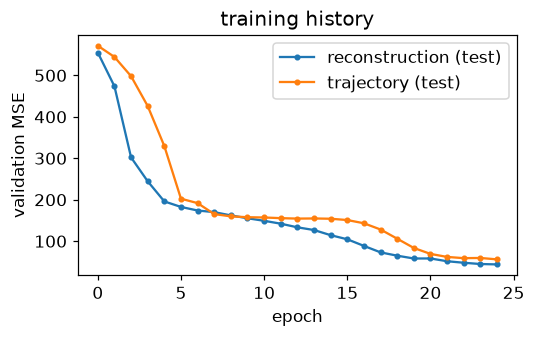

In [5]:
epochs, val_recon, val_traj, edge_spatial, adj_expr = train_vae(
    model=model, adata=adata, epochs=25, batch_size=128, learning_rate=5e-3,
    tangent_loss_params={"a": 1.0, "b": 10.0, "reg_lambda": 1.0},
    checkpoint_folder="/tmp/scitoflow_quickstart",
)

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(epochs, val_recon, "-o", ms=3, label="reconstruction (test)")
ax.plot(epochs, val_traj, "-o", ms=3, label="trajectory (test)")
ax.set_xlabel("epoch"); ax.set_ylabel("validation MSE"); ax.legend(); ax.set_title("training history")
fig.tight_layout()

## 3. Read out the inferred latent time

{meth}`scitoflow.VAE.reconstruct_latent` returns, for every spot, the latent trajectory,
the latent velocity, the inferred latent time, and the niche factor. Because we used the
dual GNN (`use_expr_gnn=True`), we pass both the spatial and the expression graph. The
expression neighbor list from training is converted to an edge index with the model helper.

In [6]:
model.eval()
data = {st: torch.tensor(adata.layers[model.topo.layer[st]].toarray(), dtype=torch.float64)
        for st in model.topo.states}
edge_expr = model._adj_to_edge_index(adj_expr.cpu())

with torch.no_grad():
    _, latent_full, velocity, latent_time, h = model.reconstruct_latent(
        data, edge_index_spatial=edge_spatial.cpu(), edge_index_expression=edge_expr)

t_inferred = latent_time.cpu().numpy()
t_true = adata.obs["latent_time"].values
rho = spearmanr(t_inferred, t_true).statistic
print(f"Spearman(inferred latent time, ground truth) = {rho:.3f}")

Spearman(inferred latent time, ground truth) = -0.992


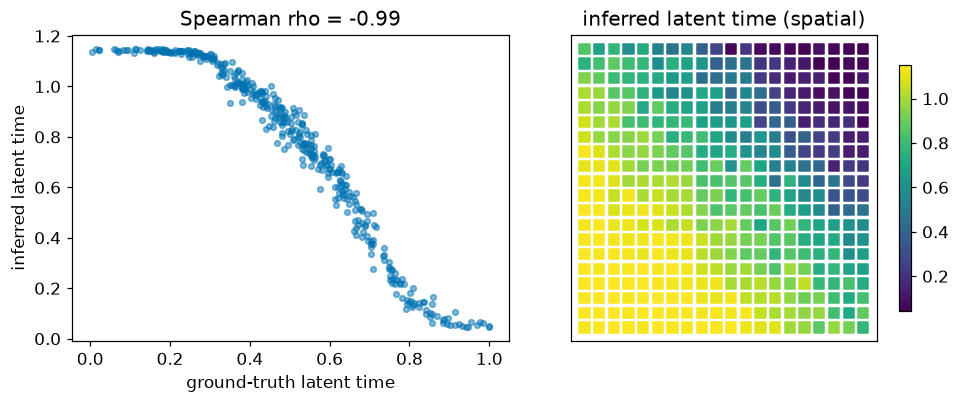

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
axes[0].scatter(t_true, t_inferred, s=14, alpha=0.5, color="#0072B2")
axes[0].set_xlabel("ground-truth latent time"); axes[0].set_ylabel("inferred latent time")
axes[0].set_title(f"Spearman rho = {rho:.2f}")

sc = axes[1].scatter(x, y, c=t_inferred, cmap="viridis", s=45, marker="s")
axes[1].set_title("inferred latent time (spatial)")
axes[1].set_aspect("equal"); axes[1].set_xticks([]); axes[1].set_yticks([])
plt.colorbar(sc, ax=axes[1], shrink=0.8)
fig.tight_layout()

In only a few epochs the inferred latent time recovers the spatial gradient. Latent time
is defined up to an orientation, so a strong monotone (Spearman) relationship, positive or
negative, is the thing to look for, not a 45-degree line.

## Next

- {doc}`02_modality_topologies` - run the same model on subsets of the modalities.
- {doc}`03_training_and_readouts` - the niche factor, velocity streamlines, a within-model
  niche counterfactual, and the optional time prior.